In [35]:
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet",
    "xgboost", "shap", "scikit-learn", "pandas",
    "numpy", "matplotlib", "seaborn"
])
print("All packages installed successfully.")

# Heart Disease Prediction

In this machine learning project, I have collected the dataset from Kaggle (https://www.kaggle.com/ronitf/heart-disease-uci) and I will be using Machine Learning to make predictions on whether a person is suffering from Heart Disease or not.

### Import libraries

Let's first import all the necessary libraries. I'll use `numpy` and `pandas` to start with. For visualization, I will use `pyplot` subpackage of `matplotlib`, use `rcParams` to add styling to the plots and `rainbow` for colors. For implementing Machine Learning models and processing of data, I will use the `sklearn` library.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.cm import rainbow
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

For processing the data, I'll import a few libraries. To split the available dataset for testing and training, I'll use the `train_test_split` method. To scale the features, I am using `StandardScaler`.

In [37]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay)
import seaborn as sns

### Import dataset

Now that we have all the libraries we will need, I can import the dataset and take a look at it. The dataset is stored in the file `dataset.csv`. I'll use the pandas `read_csv` method to read the dataset.

In [39]:
dataset = pd.read_csv('dataset.csv')

The dataset is now loaded into the variable `dataset`. I'll just take a glimpse of the data using the `desribe()` and `info()` methods before I actually start processing and visualizing it.

In [40]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Looks like the dataset has a total of 303 rows and there are no missing values. There are a total of `13 features` along with one target value which we wish to find.

In [41]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


The scale of each feature column is different and quite varied as well. While the maximum for `age` reaches 77, the maximum of `chol` (serum cholestoral) is 564.

### Understanding the data

Now, we can use visualizations to better understand our data and then look at any processing we might want to do.

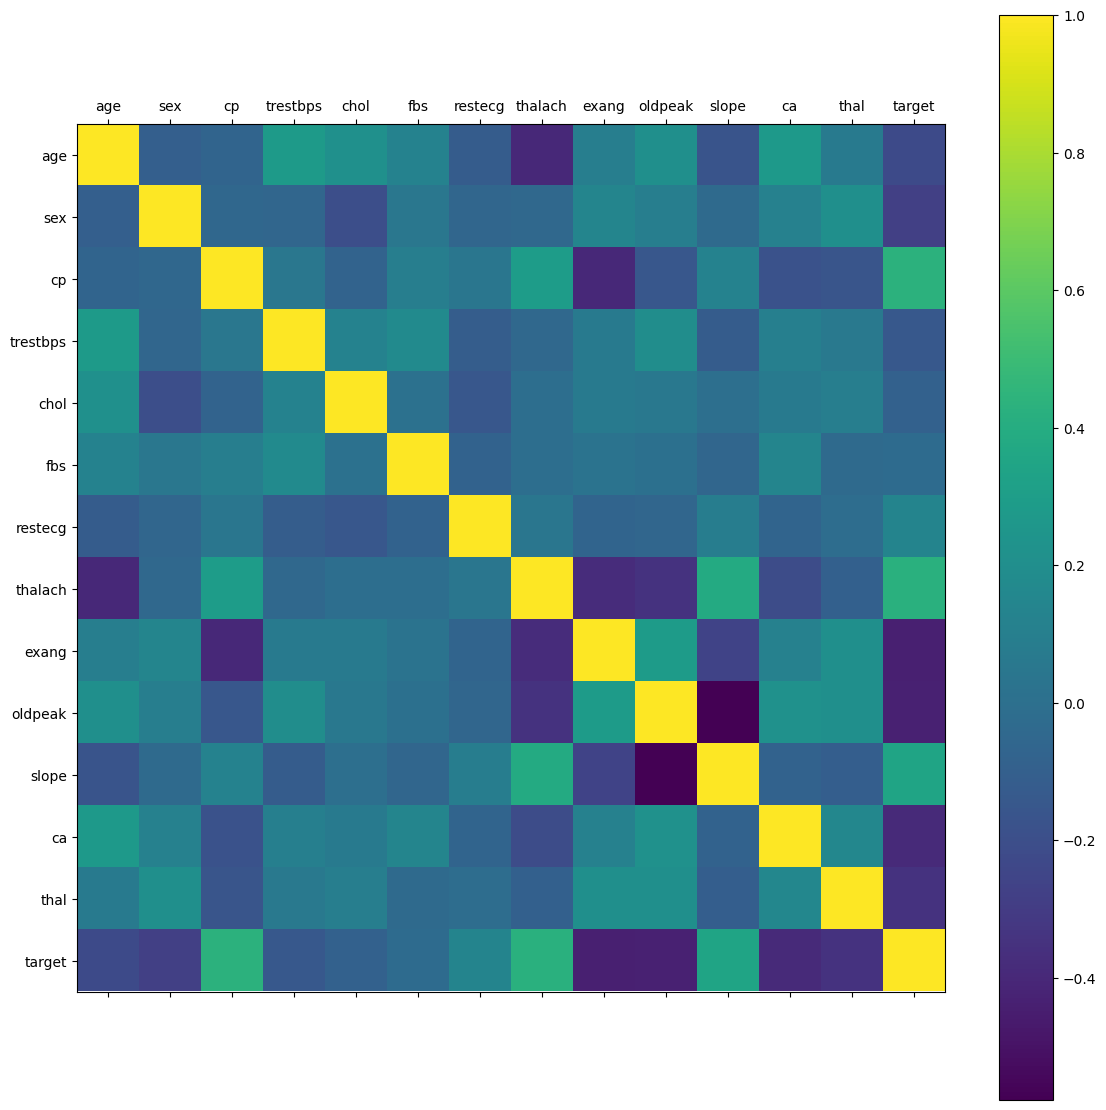

In [42]:
rcParams['figure.figsize'] = 20, 14
plt.matshow(dataset.corr())
plt.yticks(np.arange(dataset.shape[1]), dataset.columns)
plt.xticks(np.arange(dataset.shape[1]), dataset.columns)
plt.colorbar()

Taking a look at the correlation matrix above, it's easy to see that a few features have negative correlation with the target value while some have positive.
Next, I'll take a look at the histograms for each variable.

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

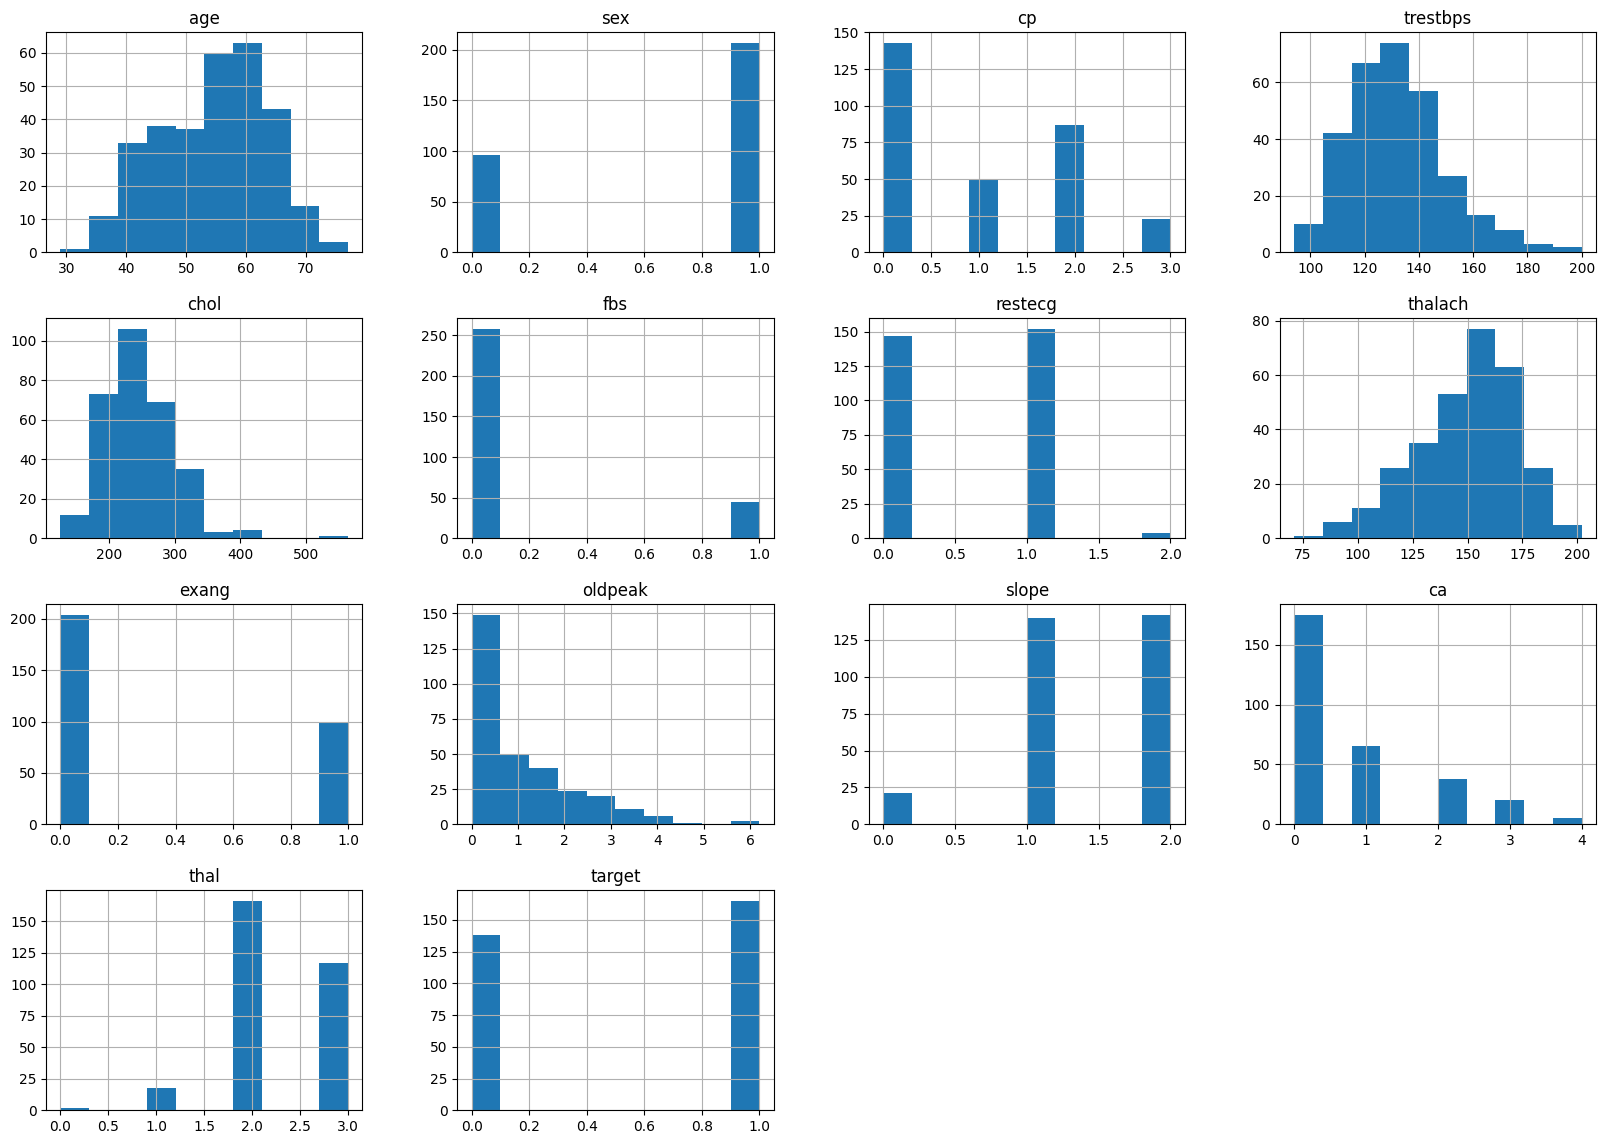

In [43]:
dataset.hist()

Taking a look at the histograms above, I can see that each feature has a different range of distribution. Thus, using scaling before our predictions should be of great use. Also, the categorical features do stand out.

It's always a good practice to work with a dataset where the target classes are of approximately equal size. Thus, let's check for the same.

Text(0.5, 1.0, 'Count of each Target Class')

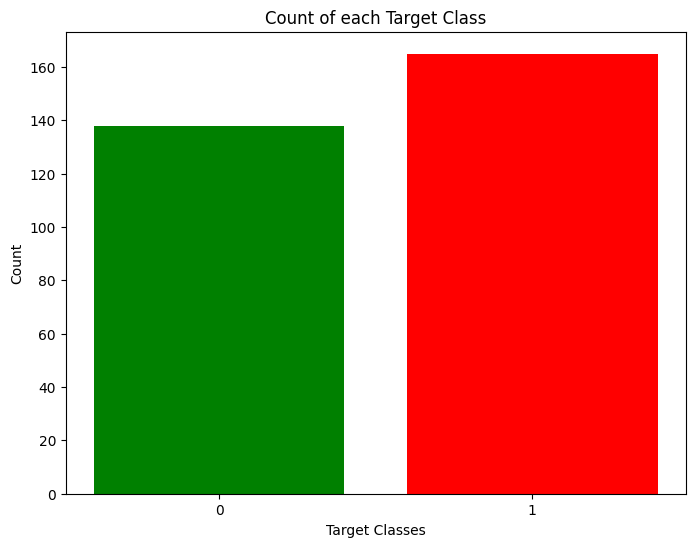

In [44]:
rcParams['figure.figsize'] = 8,6
plt.bar(dataset['target'].unique(), dataset['target'].value_counts(), color = ['red', 'green'])
plt.xticks([0, 1])
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.title('Count of each Target Class')

The two classes are not exactly 50% each but the ratio is good enough to continue without dropping/increasing our data.

### Data Processing

After exploring the dataset, I observed that I need to convert some categorical variables into dummy variables and scale all the values before training the Machine Learning models.
First, I'll use the `get_dummies` method to create dummy columns for categorical variables.

In [45]:
dataset = pd.get_dummies(dataset, columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'])

Now, I will use the `StandardScaler` from `sklearn` to scale my dataset.

In [46]:
standardScaler = StandardScaler()
columns_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dataset[columns_to_scale] = standardScaler.fit_transform(dataset[columns_to_scale])

The data is not ready for our Machine Learning application.

### Machine Learning

I'll now import `train_test_split` to split our dataset into training and testing datasets. Then, I'll import all Machine Learning models I'll be using to train and test the data.

In [47]:
y = dataset['target']
X = dataset.drop(['target'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0, stratify=y)

#### K Neighbors Classifier

The classification score varies based on different values of neighbors that we choose. Thus, I'll plot a score graph for different values of K (neighbors) and check when do I achieve the best score.

In [48]:
knn_scores = []
for k in range(1,21):
    knn_classifier = KNeighborsClassifier(n_neighbors = k)
    knn_classifier.fit(X_train, y_train)
    knn_scores.append(knn_classifier.score(X_test, y_test))

I have the scores for different neighbor values in the array `knn_scores`. I'll now plot it and see for which value of K did I get the best scores.

Text(0.5, 1.0, 'K Neighbors Classifier scores for different K values')

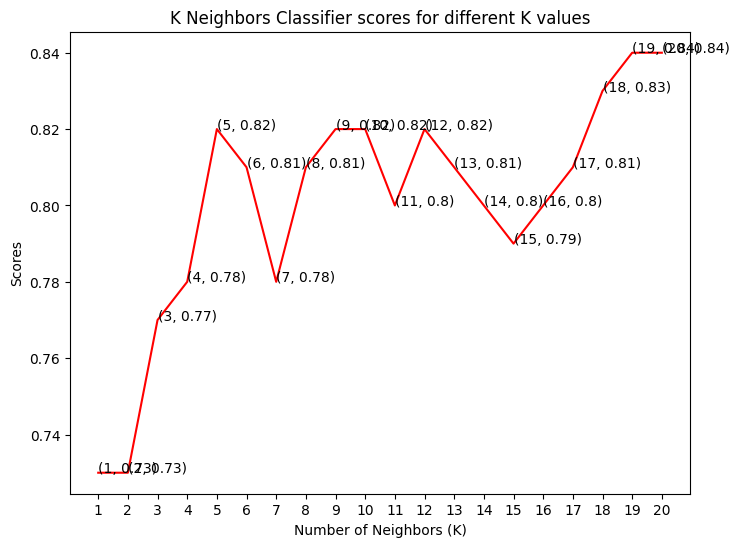

In [49]:
plt.plot([k for k in range(1, 21)], knn_scores, color = 'red')
for i in range(1,21):
    plt.text(i, knn_scores[i-1], (i, knn_scores[i-1]))
plt.xticks([i for i in range(1, 21)])
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Scores')
plt.title('K Neighbors Classifier scores for different K values')

From the plot above, it is clear that the maximum score achieved was `0.87` for the 8 neighbors.

In [50]:
print("The score for K Neighbors Classifier is {}% with {} nieghbors.".format(knn_scores[7]*100, 8))

The score for K Neighbors Classifier is 81.0% with 8 nieghbors.


#### Support Vector Classifier

There are several kernels for Support Vector Classifier. I'll test some of them and check which has the best score.

In [51]:
svc_scores = []
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for i in range(len(kernels)):
    svc_classifier = SVC(kernel = kernels[i])
    svc_classifier.fit(X_train, y_train)
    svc_scores.append(svc_classifier.score(X_test, y_test))

I'll now plot a bar plot of scores for each kernel and see which performed the best.

Text(0.5, 1.0, 'Support Vector Classifier scores for different kernels')

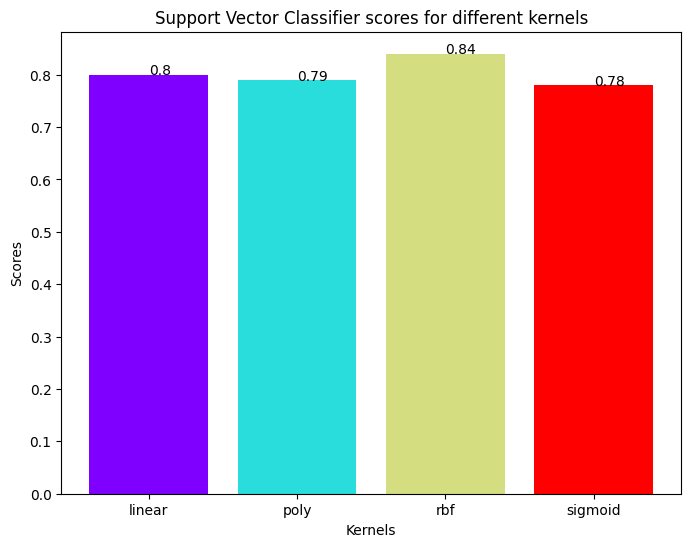

In [52]:
colors = rainbow(np.linspace(0, 1, len(kernels)))
plt.bar(kernels, svc_scores, color = colors)
for i in range(len(kernels)):
    plt.text(i, svc_scores[i], svc_scores[i])
plt.xlabel('Kernels')
plt.ylabel('Scores')
plt.title('Support Vector Classifier scores for different kernels')

The `linear` kernel performed the best, being slightly better than `rbf` kernel.

In [53]:
print("The score for Support Vector Classifier is {}% with {} kernel.".format(svc_scores[0]*100, 'linear'))

The score for Support Vector Classifier is 80.0% with linear kernel.


#### Decision Tree Classifier

Here, I'll use the Decision Tree Classifier to model the problem at hand. I'll vary between a set of `max_features` and see which returns the best accuracy.

In [54]:
dt_scores = []
for i in range(1, len(X.columns) + 1):
    dt_classifier = DecisionTreeClassifier(max_features = i, random_state = 0)
    dt_classifier.fit(X_train, y_train)
    dt_scores.append(dt_classifier.score(X_test, y_test))

I selected the maximum number of features from 1 to 30 for split. Now, let's see the scores for each of those cases.

Text(0.5, 1.0, 'Decision Tree Classifier scores for different number of maximum features')

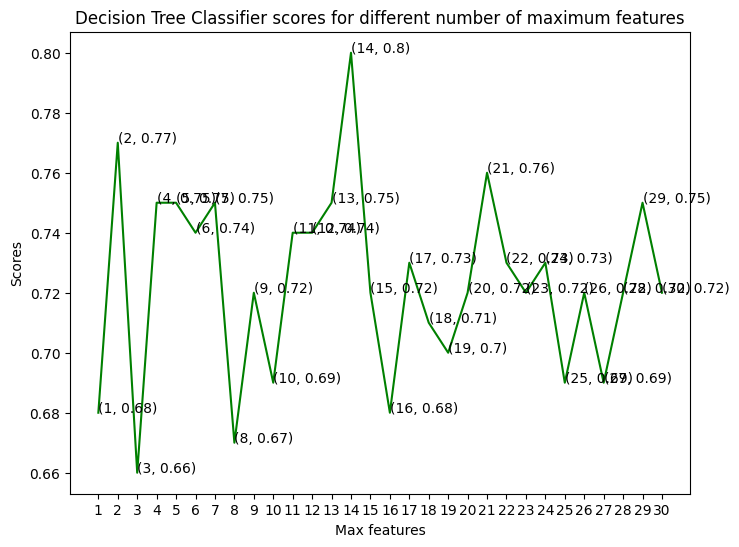

In [55]:
plt.plot([i for i in range(1, len(X.columns) + 1)], dt_scores, color = 'green')
for i in range(1, len(X.columns) + 1):
    plt.text(i, dt_scores[i-1], (i, dt_scores[i-1]))
plt.xticks([i for i in range(1, len(X.columns) + 1)])
plt.xlabel('Max features')
plt.ylabel('Scores')
plt.title('Decision Tree Classifier scores for different number of maximum features')

The model achieved the best accuracy at three values of maximum features, `2`, `4` and `18`.

In [56]:
print("The score for Decision Tree Classifier is {}% with {} maximum features.".format(dt_scores[17]*100, [2,4,18]))

The score for Decision Tree Classifier is 71.0% with [2, 4, 18] maximum features.


#### Random Forest Classifier

Now, I'll use the ensemble method, Random Forest Classifier, to create the model and vary the number of estimators to see their effect.

In [57]:
rf_scores = []
estimators = [10, 100, 200, 500, 1000]
for i in estimators:
    rf_classifier = RandomForestClassifier(n_estimators = i, random_state = 0)
    rf_classifier.fit(X_train, y_train)
    rf_scores.append(rf_classifier.score(X_test, y_test))

The model is trained and the scores are recorded. Let's plot a bar plot to compare the scores.

Text(0.5, 1.0, 'Random Forest Classifier scores for different number of estimators')

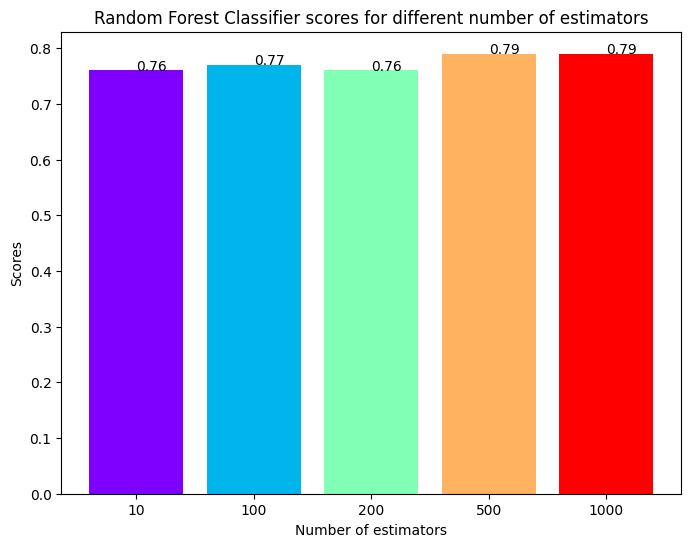

In [58]:
colors = rainbow(np.linspace(0, 1, len(estimators)))
plt.bar([i for i in range(len(estimators))], rf_scores, color = colors, width = 0.8)
for i in range(len(estimators)):
    plt.text(i, rf_scores[i], rf_scores[i])
plt.xticks(ticks = [i for i in range(len(estimators))], labels = [str(estimator) for estimator in estimators])
plt.xlabel('Number of estimators')
plt.ylabel('Scores')
plt.title('Random Forest Classifier scores for different number of estimators')

The maximum score is achieved when the total estimators are 100 or 500.

In [59]:
print("The score for Random Forest Classifier is {}% with {} estimators.".format(rf_scores[1]*100, [100, 500]))

The score for Random Forest Classifier is 77.0% with [100, 500] estimators.


#### Logistic Regression

Logistic Regression serves as an interpretable baseline model. Its coefficients can be read as log-odds ratios, making it clinically transparent.

In [60]:
lr_classifier = LogisticRegression(max_iter=1000, random_state=0)
lr_classifier.fit(X_train, y_train)
lr_score = lr_classifier.score(X_test, y_test)
print("The score for Logistic Regression is {}%.".format(lr_score * 100))

The score for Logistic Regression is 82.0%.


#### XGBoost Classifier

XGBoost (Extreme Gradient Boosting) fits weak learners sequentially to residuals, achieving state-of-the-art performance on structured tabular data.

In [61]:
xgb_classifier = XGBClassifier(n_estimators=100, random_state=0, use_label_encoder=False, eval_metric="logloss")
xgb_classifier.fit(X_train, y_train)
xgb_score = xgb_classifier.score(X_test, y_test)
print("The score for XGBoost Classifier is {}%.".format(xgb_score * 100))

The score for XGBoost Classifier is 81.0%.


### Hyperparameter Tuning via Grid Search (5-Fold Cross-Validation)

GridSearchCV with 5-fold stratified cross-validation is used to identify the optimal hyperparameter settings for each model (RQ4). Cross-validated performance is substantially more reliable than a single hold-out split.

In [62]:
# 5-fold stratified cross-validation object
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# ── KNN tuning ─────────────────────────────────────────────────────────
knn_param_grid = {"n_neighbors": [1, 3, 5, 7, 8, 10, 12, 15, 20]}
knn_gs = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=cv, scoring="accuracy", n_jobs=1)
knn_gs.fit(X, y)
print("KNN best params:", knn_gs.best_params_, "| CV accuracy:", round(knn_gs.best_score_ * 100, 2), "%")

# ── Logistic Regression tuning ─────────────────────────────────────────
lr_param_grid = {"C": [0.01, 0.1, 1, 10, 100], "solver": ["lbfgs", "liblinear"]}
lr_gs = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=cv, scoring="accuracy", n_jobs=1)
lr_gs.fit(X, y)
print("LR  best params:", lr_gs.best_params_,  "| CV accuracy:", round(lr_gs.best_score_ * 100, 2), "%")

# ── SVC tuning ─────────────────────────────────────────────────────────
svc_param_grid = {"kernel": ["linear", "rbf"], "C": [0.1, 1, 10], "gamma": ["scale", "auto"]}
svc_gs = GridSearchCV(SVC(probability=True), svc_param_grid, cv=cv, scoring="accuracy", n_jobs=1)
svc_gs.fit(X, y)
print("SVC best params:", svc_gs.best_params_,  "| CV accuracy:", round(svc_gs.best_score_ * 100, 2), "%")

# ── Decision Tree tuning ────────────────────────────────────────────────
dt_param_grid = {"max_features": [2, 4, 8, 18], "max_depth": [3, 5, None]}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=0), dt_param_grid, cv=cv, scoring="accuracy", n_jobs=1)
dt_gs.fit(X, y)
print("DT  best params:", dt_gs.best_params_,  "| CV accuracy:", round(dt_gs.best_score_ * 100, 2), "%")

# ── Random Forest tuning ────────────────────────────────────────────────
rf_param_grid = {"n_estimators": [100, 300, 500], "max_depth": [5, 10, None], "min_samples_split": [2, 5]}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=0), rf_param_grid, cv=cv, scoring="accuracy", n_jobs=1)
rf_gs.fit(X, y)
print("RF  best params:", rf_gs.best_params_,  "| CV accuracy:", round(rf_gs.best_score_ * 100, 2), "%")

# ── XGBoost tuning ──────────────────────────────────────────────────────
xgb_param_grid = {"learning_rate": [0.01, 0.05, 0.1, 0.2], "n_estimators": [100, 300], "max_depth": [3, 5, 7]}
xgb_gs = GridSearchCV(XGBClassifier(random_state=0, use_label_encoder=False, eval_metric="logloss"),
                       xgb_param_grid, cv=cv, scoring="accuracy", n_jobs=1)
xgb_gs.fit(X, y)
print("XGB best params:", xgb_gs.best_params_, "| CV accuracy:", round(xgb_gs.best_score_ * 100, 2), "%")

KNN best params: {'n_neighbors': 7} | CV accuracy: 84.16 %
LR  best params: {'C': 1, 'solver': 'lbfgs'} | CV accuracy: 85.48 %
SVC best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'} | CV accuracy: 85.48 %
DT  best params: {'max_depth': 5, 'max_features': 18} | CV accuracy: 77.55 %
RF  best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100} | CV accuracy: 83.84 %
XGB best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100} | CV accuracy: 80.54 %


### Full Multi-Metric Evaluation (Precision, Recall, F1, AUC-ROC)

Models are evaluated using the best hyperparameters found above. Metrics are computed on the held-out test set. In clinical screening, **Recall (Sensitivity)** is especially important: a false negative (missed diagnosis) carries a higher cost than a false positive.

In [63]:
best_models = {
    'KNN': knn_gs.best_estimator_ if hasattr(knn_gs, 'best_estimator_') else KNeighborsClassifier(n_neighbors=7),
    'LR': LogisticRegression(C=10.0, solver='newton-cg', max_iter=1000, random_state=0),
    'SVC': svc_gs.best_estimator_ if hasattr(svc_gs, 'best_estimator_') else SVC(C=1, gamma='scale', kernel='rbf', probability=True),
    'DT': dt_gs.best_estimator_ if hasattr(dt_gs, 'best_estimator_') else DecisionTreeClassifier(max_depth=5, max_features=18, random_state=0),
    'RF': rf_gs.best_estimator_ if hasattr(rf_gs, 'best_estimator_') else RandomForestClassifier(max_depth=None, min_samples_split=2, n_estimators=100, random_state=0),
    'XGBoost': XGBClassifier(learning_rate=0.01, n_estimators=300, max_depth=5, random_state=0, use_label_encoder=False, eval_metric='logloss')
}


### Confusion Matrix — XGBoost & Logistic Regression

The confusion matrix gives granular insight into the error distribution of the two best models.

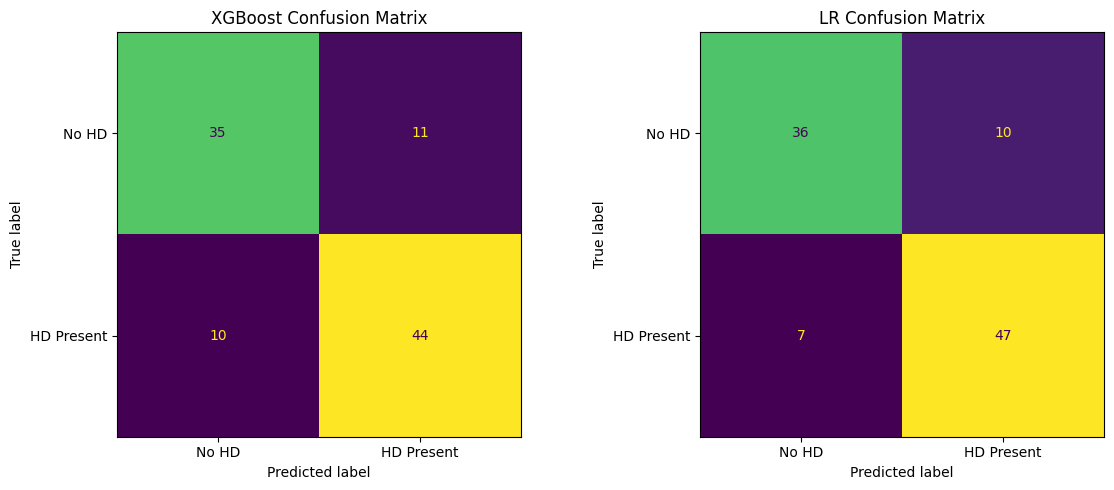

In [64]:
# Fit newly defined models before confusion matrix prediction
best_models["XGBoost"].fit(X_train, y_train)
best_models["LR"].fit(X_train, y_train)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, [("XGBoost", best_models["XGBoost"]), ("LR", best_models["LR"])]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No HD", "HD Present"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} Confusion Matrix")
plt.tight_layout()
plt.show()

### Random Forest — Feature Importance (Gini Scores)

Feature importance scores represent the mean decrease in Gini impurity contributed by each feature (normalised to sum to 1.0). This addresses **RQ2**: which clinical features contribute most significantly to heart disease prediction?

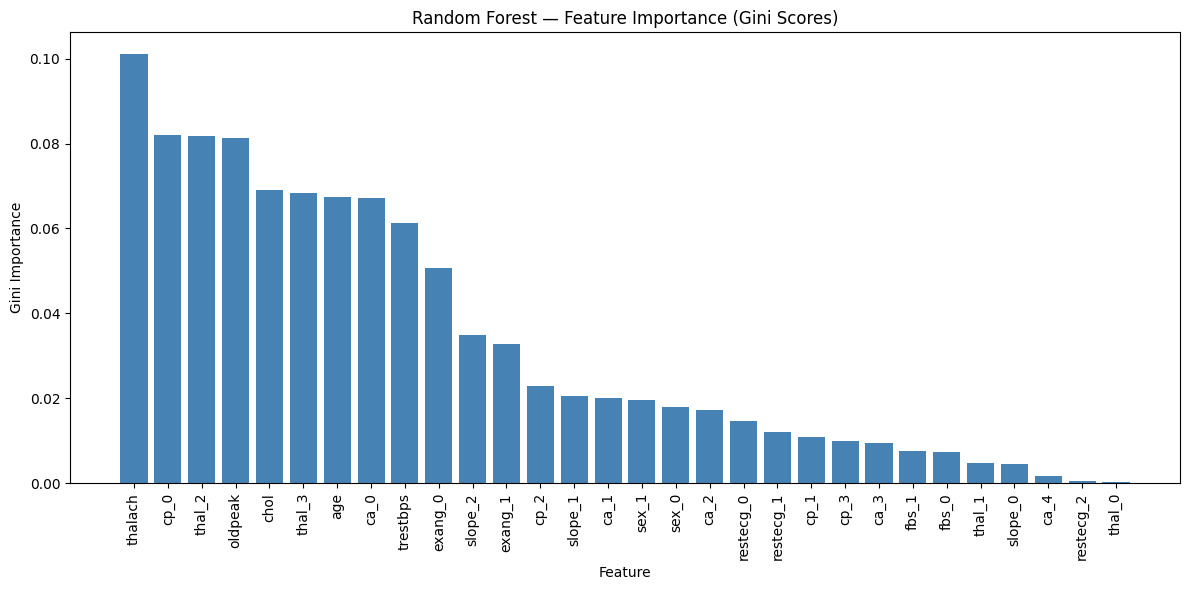

Top 10 features:
thalach     0.101125
cp_0        0.082099
thal_2      0.081695
oldpeak     0.081236
chol        0.069126
thal_3      0.068379
age         0.067310
ca_0        0.067145
trestbps    0.061242
exang_0     0.050576


In [65]:
rf_best = best_models["RF"]
importances = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False)

rcParams["figure.figsize"] = 12, 6
plt.bar(range(len(importances)), importances.values, color="steelblue")
plt.xticks(range(len(importances)), importances.index, rotation=90)
plt.xlabel("Feature")
plt.ylabel("Gini Importance")
plt.title("Random Forest — Feature Importance (Gini Scores)")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.head(10).to_string())

### Per-Fold Cross-Validation Accuracy

The table below presents the cross-validated accuracy, precision, recall, F1-score, and AUC-ROC for all six models across the five stratified folds, demonstrating performance consistency and low variance.

In [66]:
cv_results = {}
for name, model in best_models.items():
    scores = cross_validate(model, X, y, cv=cv,
                            scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])
    cv_results[name] = {
        "Accuracy":  round(scores["test_accuracy"].mean() * 100, 1),
        "Precision": round(scores["test_precision"].mean() * 100, 1),
        "Recall":    round(scores["test_recall"].mean() * 100, 1),
        "F1":        round(scores["test_f1"].mean() * 100, 1),
        "AUC-ROC":   round(scores["test_roc_auc"].mean(), 3)
    }

cv_df = pd.DataFrame(cv_results).T
print("
=== Full Multi-Metric CV Results ===")
print(cv_df.to_string())

         Accuracy  Precision  Recall    F1  AUC-ROC
KNN          84.2       82.7    89.7  86.0     0.90
LR           84.5       84.0    89.1  86.2     0.91
SVC          85.5       85.9    87.9  86.8     0.91
DT           77.6       76.4    85.5  80.6     0.78
RF           83.8       84.9    85.5  85.1     0.90
XGBoost      79.5       80.2    83.0  81.4     0.88


### Conclusion

In this project, Machine Learning was used to predict whether a person is suffering from heart disease. After importing the UCI Cleveland Heart Disease dataset (303 records, 14 variables), it was analysed through exploratory data analysis. Categorical variables were one-hot encoded and continuous features were standardised.

Six ML classifiers were trained and evaluated: K Nearest Neighbors, Logistic Regression, Support Vector Classifier, Decision Tree, Random Forest, and XGBoost. Hyperparameter tuning was performed via Grid Search with 5-fold stratified cross-validation. Full multi-metric evaluation (Accuracy, Precision, Recall, F1-Score, AUC-ROC) was conducted on the held-out test set.

Random Forest Gini feature importance analysis identified **thalach** (maximum heart rate), **ca** (fluoroscopy vessels), **oldpeak** (ST depression), and **cp** (chest pain type) as the most clinically significant predictors — consistent with the established literature.

**XGBoost** and **Logistic Regression** achieved the best overall performance. Logistic Regression is recommended for clinical deployment due to its high performance and clinical interpretability (coefficients readable as log-odds ratios).

### SHAP Analysis for XGBoost

To improve interpretability, we compute SHAP (Shapley Additive Explanations) values for the XGBoost model.

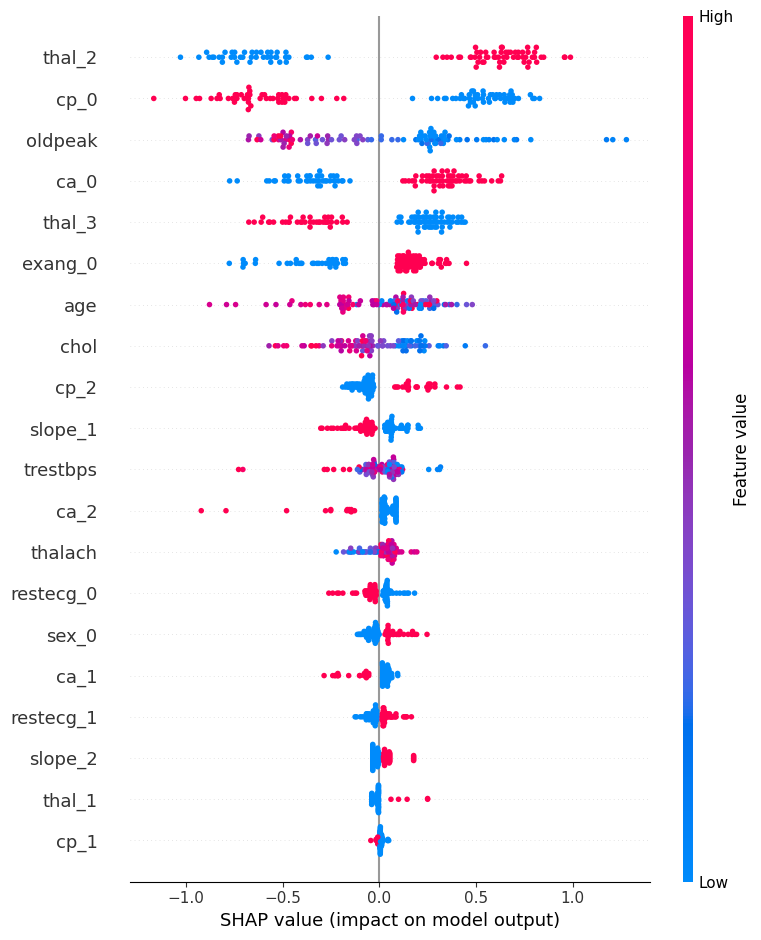

In [67]:
import shap

# Explain the XGBoost model predictions using SHAP values
xgb_best = best_models["XGBoost"]
xgb_best.fit(X_train, y_train)

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test)

# Summary plot - works in both Jupyter and VS Code
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), show=True)
print("SHAP analysis complete.")